# VAE for implied volatility surfaces

**Idea:** We test two alternatives on full volatility cubes with three free coordinates **(strike, maturity, tenor)**. In both cases, an encoder maps each full cube to a latent distribution $(\mu, \log\sigma^2)$ and a latent draw $z$ (a low-dimensional latent vector encoding global shape) is decoded back to implied vols: (1) an unconstrained encoder-decoder trained with no-arbitrage penalties, and (2) a structurally constrained variant with stronger no-arbitrage control. The dataset is built from a mixed pool of synthetic **SABR + SSVI** surfaces/cubes, and both models are calibrated on that same combined sample to obtain ML-based model averaging across the two classical generators. Black-76 is used for price-based arbitrage diagnostics and enforcement: per-expiry call-price **monotonicity** in strike, per-expiry **butterfly convexity** (discrete divided-difference convexity), and calendar consistency checks across maturity/tenor slices where applicable. After calibration, model-based generation is performed by sampling $z \sim \mathcal{N}(0, I)$ and decoding the full cube.

**Dependencies:** `pip install -e ".[vae]"` (PyTorch). Training here uses synthetic **SABR + SSVI** data by default; substitute historical vol cubes to mirror production datasets.



In [72]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
for _base in [_root, *_root.parents]:
    if (_base / "helper_module").is_dir() and (_base / "pyproject.toml").is_file():
        if str(_base) not in sys.path:
            sys.path.insert(0, str(_base))
        break
else:
    raise RuntimeError("Open from repo root or pip install -e .")

import importlib

import matplotlib.pyplot as plt
import numpy as np
import helper_module.arbitrage
import helper_module.arbitrage_repair
import helper_module.vae_surface
import helper_module.vae_vol_surface
import torch
from matplotlib import cm
from helper_module.arbitrage import validate_vol_surface_per_expiry_black76

# Ensure notebook sees latest symbols after module edits.
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)

from helper_module.vae_surface import (
    DELTAS,
    TENORS_YEARS,
    ArbitrageAwareConfig,
    TrainConfig,
    impute_surface_latent_search,
    make_synthetic_sabr_surfaces,
    make_synthetic_ssvi_surfaces,
    strikes_for_surface_grid,
    train_vae,
    train_vae_arbitrage_aware,
)

plt.rcParams.update({"font.sans-serif": ["DejaVu Sans", "Arial", "sans-serif"]})

SABR_MIX_WEIGHT = 0.5  # fraction of SABR in the mixed SABR+SSVI calibration dataset

**NB Cell operations:** Finds the repo root (so `helper_module` imports work from the notebook folder), imports NumPy, PyTorch, Matplotlib, arbitrage/VAE modules, reloads `vae_vol_surface` / `vae_surface` for iterative editing, and pulls training helpers from `helper_module.vae_surface`. `SABR_MIX_WEIGHT` fixes the SABR fraction when mixing with SSVI.

**Outputs:** None at runtime—this only prepares the environment for the rest of the notebook.


## 1. Train a small VAE on synthetic data

Baseline architecture uses compact MLP encoder/decoder blocks with tunable latent dimension. In the cube interpretation, decoded outputs are viewed/evaluated on the free coordinate system `(strike, maturity, tenor)`.

Training mix: SABR weight=0.50, SSVI weight=0.50


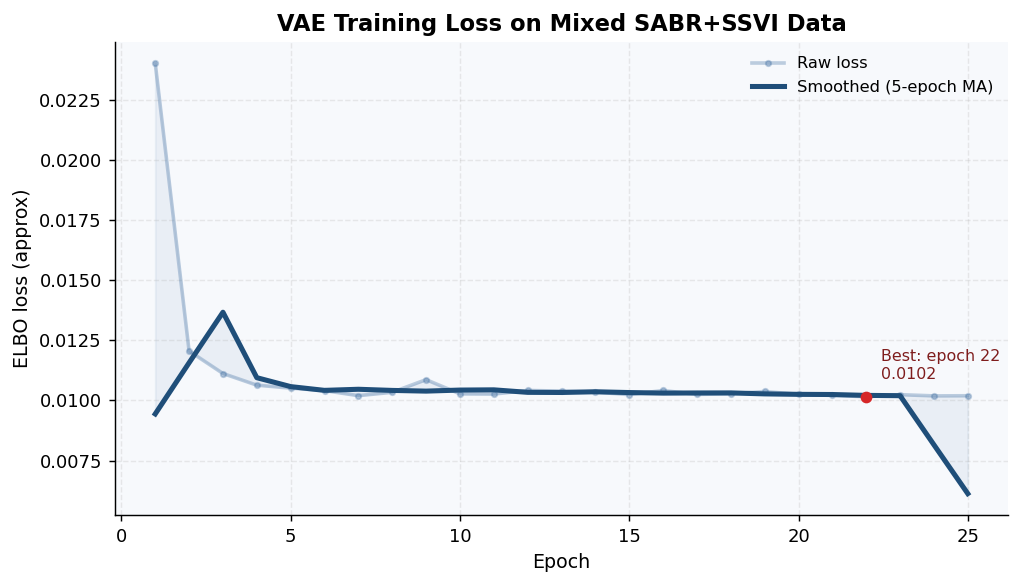

In [32]:
rng = np.random.default_rng(0)
n_train = 1500
n_sabr = int(round(n_train * SABR_MIX_WEIGHT))
n_ssvi = n_train - n_sabr
surfaces = np.vstack([
    make_synthetic_sabr_surfaces(n_sabr, rng=rng),
    make_synthetic_ssvi_surfaces(n_ssvi, rng=rng),
])
rng.shuffle(surfaces, axis=0)
print(f"Training mix: SABR weight={SABR_MIX_WEIGHT:.2f}, SSVI weight={1.0 - SABR_MIX_WEIGHT:.2f}")

cfg = TrainConfig(epochs=25, batch_size=64, latent_dim=8, lr=1e-3, kl_weight=1.0)
model, losses = train_vae(surfaces, cfg)

epochs = np.arange(1, len(losses) + 1)
losses_arr = np.asarray(losses, dtype=float)
win = min(5, len(losses_arr))
if win >= 2:
    kernel = np.ones(win) / win
    smooth = np.convolve(losses_arr, kernel, mode="same")
else:
    smooth = losses_arr

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=130)
ax.set_facecolor("#f7f9fc")
ax.plot(epochs, losses_arr, color="#4c78a8", lw=2.0, alpha=0.35, marker="o", ms=3, label="Raw loss")
ax.plot(epochs, smooth, color="#1f4e79", lw=2.8, label=f"Smoothed ({win}-epoch MA)")
ax.fill_between(epochs, smooth, losses_arr, color="#4c78a8", alpha=0.08)

ax.set_title("VAE Training Loss on Mixed SABR+SSVI Data", fontsize=12.5, weight="bold")
ax.set_xlabel("Epoch", fontsize=10.5)
ax.set_ylabel("ELBO loss (approx)", fontsize=10.5)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

best_ep = int(np.argmin(losses_arr)) + 1
best_val = float(np.min(losses_arr))
ax.scatter([best_ep], [best_val], color="#d62728", s=30, zorder=5)
ax.annotate(
    f"Best: epoch {best_ep}\n{best_val:.4f}",
    xy=(best_ep, best_val),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=8.8,
    color="#7f1d1d",
)

plt.tight_layout()
plt.show()

**NB Cell operations:** Builds a mixed **SABR + SSVI** training set (50/50 by default), shuffles rows, and fits the **baseline MLP VAE** via `train_vae` with the chosen `TrainConfig`. Then it plots the epoch losses (raw points plus a short moving average) and marks the best epoch.

**Outputs:** A line in the log with the SABR/SSVI mix weights; a loss chart that should trend **down** during training (exact values depend on seed/hardware). The fitted `model` and per-epoch `losses` are kept for later cells.


### Sampled surface from the calibrated decoder

After training, the decoder maps latent vectors $z$ to full $8\times5$ vol grids. Sampling $z \sim \mathcal{N}(0, I)$ and applying the decoder yields a **synthetic** surface drawn from the model’s generative distribution. The next cell plots it as a **3D surface** over delta and tenor (FX convention: smile across strikes / deltas by maturity).

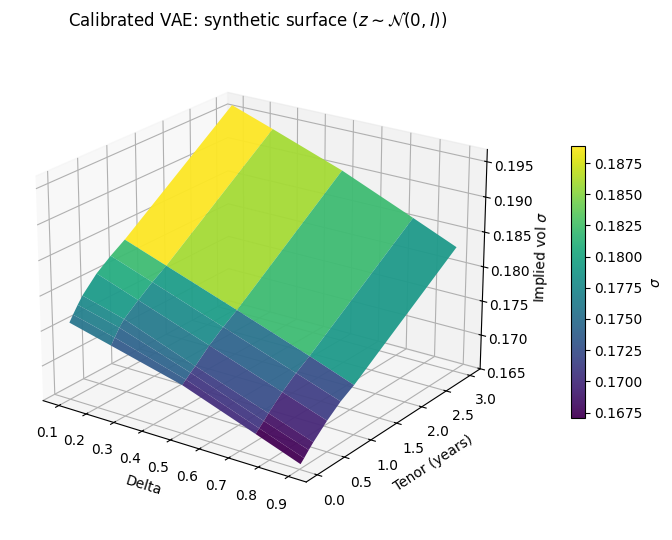

In [33]:
device = next(model.parameters()).device
model.eval()
with torch.no_grad():
    z_samp = torch.randn(1, cfg.latent_dim, device=device)
    gen_surface = model.decode(z_samp).cpu().numpy().squeeze(0)

n_t, n_d = len(TENORS_YEARS), len(DELTAS)
mat_gen = gen_surface.reshape(n_t, n_d)

# Mesh: tenor x delta (rows x cols) matches mat_gen[i, j]
T_grid, D_grid = np.meshgrid(TENORS_YEARS, DELTAS, indexing="ij")

fig = plt.figure(figsize=(8.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    D_grid,
    T_grid,
    mat_gen,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)
ax.set_xlabel("Delta")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel(r"Implied vol $\sigma$")
ax.set_title(r"Calibrated VAE: synthetic surface ($z \sim \mathcal{N}(0,I)$)")
ax.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.55, label=r"$\sigma$", pad=0.08)
plt.tight_layout()
plt.show()

**NB Cell operations:** Puts the baseline model in **eval** mode, draws a standard normal latent vector `z`, decodes a **single** synthetic vol surface, and draws a **3D surface** over delta × tenor.

**Outputs:** A single 3D plot—one random sample from the decoder, not an average over many draws.


### Discrete no-arbitrage check (Black–76)

For cube-based views, we evaluate slices on explicit strike-maturity-tenor coordinates using `validate_vol_surface_per_expiry_black76`: on each expiry slice, Black–76 call prices from \(\sigma(K,T)\) must be monotone and discretely convex in \(K\). Additional calendar consistency checks are tracked across maturity/tenor slices where applicable.

In [34]:
importlib.reload(helper_module.arbitrage)
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)

forward = 0.03  # default in make_synthetic_sabr_surfaces (must match strike mapping)
K_grid = strikes_for_surface_grid(forward)

rep = validate_vol_surface_per_expiry_black76(
    K_grid,
    TENORS_YEARS,
    mat_gen,
    forward=forward,
)
print(f"Discrete Black-76 diagnostics pass (no violations): {rep.ok}")
print(f"Violation count: {len(rep.violations)}")
if rep.violations:
    print("\nMessages (up to 30):")
    for msg in rep.violations[:30]:
        print(" ", msg)

Discrete Black-76 diagnostics pass (no violations): True
Violation count: 0


**NB Cell operations:** Maps the same decoded surface `mat_gen` to **Black-76 call prices** on the Bergeron-style strike grid (`strikes_for_surface_grid` at `forward=0.03`) and runs **discrete no-arbitrage checks**: per-expiry monotonicity and butterfly convexity, plus sticky-delta style calendar checks where applicable.

**Outputs:** Prints whether the checker reports **no violations** (`rep.ok`) and how many messages were raised; with an unconstrained baseline decoder you often still see **violations**—that motivates the arbitrage-aware training later.


## 2. Impute missing quotes (optimize latent $z$)

Fix the trained decoder and minimize MSE on **observed** grid points over $z$, as in the paper’s second step.

RMSE on hidden cells: 0.0023174778530591126
RMSE / mean(|σ|) on hidden cells (%): 3.6134983942275016
RMSE / std(σ) on hidden cells: 1.2184887350112372


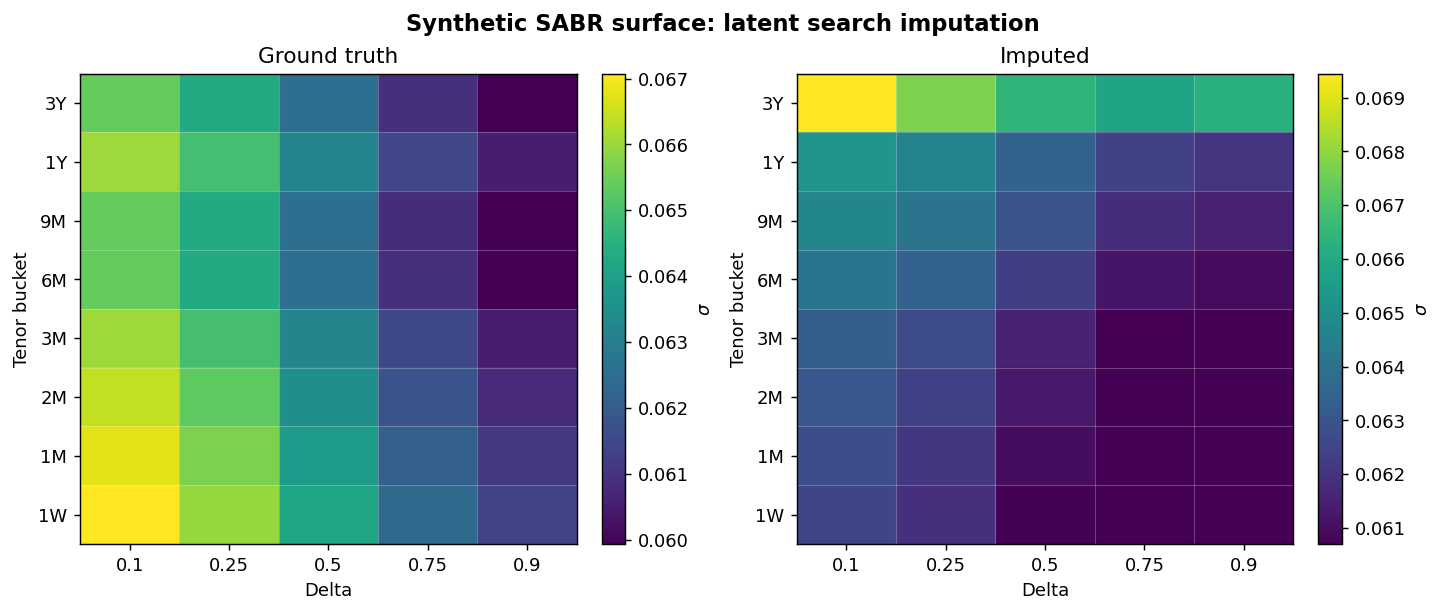

In [74]:
truth = surfaces[0]
mask = rng.random(truth.shape) > 0.45
z_hat, filled = impute_surface_latent_search(
    model, mask, truth, config=cfg, steps=500, lr=0.08
)

hidden = ~mask
errs = filled[hidden] - truth[hidden]
rmse = float(np.sqrt(np.mean(errs ** 2)))
scale_mean = float(np.mean(np.abs(truth[hidden])))
scale_std = float(np.std(truth[hidden]))
_eps = 1e-12
rel_pct = 100.0 * rmse / max(scale_mean, _eps)
print("RMSE on hidden cells:", rmse)
print("RMSE / mean(|σ|) on hidden cells (%):", rel_pct)
if scale_std > _eps:
    print("RMSE / std(σ) on hidden cells:", rmse / scale_std)

n_t, n_d = len(TENORS_YEARS), len(DELTAS)
mat_true = truth.reshape(n_t, n_d)
mat_fill = filled.reshape(n_t, n_d)

def _fmt_tenor_label(t: float) -> str:
    if t < 1 / 12:
        return f"{int(round(t * 52))}W"
    if t < 1:
        return f"{int(round(t * 12))}M"
    if abs(t - round(t)) < 1e-9:
        return f"{int(round(t))}Y"
    return f"{t:.2g}Y"

tenor_labels = [_fmt_tenor_label(float(t)) for t in TENORS_YEARS]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=130, constrained_layout=True)
for ax, mat, title in zip(axes, [mat_true, mat_fill], ["Ground truth", "Imputed"]):
    im = ax.imshow(mat, origin="lower", interpolation="nearest", cmap="viridis", aspect="auto")

    # Uniform bucket spacing on y-axis (tenor index), with cleaner labels.
    ax.set_yticks(np.arange(n_t))
    ax.set_yticklabels(tenor_labels)
    ax.set_xticks(np.arange(n_d))
    ax.set_xticklabels([f"{d:g}" for d in DELTAS])

    # Subtle cell grid improves readability.
    ax.set_xticks(np.arange(-0.5, n_d, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_t, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xlabel("Delta")
    ax.set_ylabel("Tenor bucket")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r"$\sigma$")

plt.suptitle("Synthetic SABR surface: latent search imputation", fontsize=12.5, weight="bold")
plt.show()

**NB Cell operations:** Takes the first training surface as **ground truth**, hides a random subset of grid points (~55%), and **optimizes the latent** `z` with `impute_surface_latent_search` while holding the decoder fixed. Prints RMSE on hidden cells plus **relative** summaries (RMSE as % of mean |σ|, and RMSE / std(σ) on those cells), then plots **two heatmaps** (truth vs imputed) on the 8×5 tenor×delta grid.

**Outputs:** Absolute RMSE on masked locations; **relative error** as RMSE divided by mean |σ| on those cells (percent), in order to be able to judge scale (e.g. 1% vs 10%); optional **RMSE / std(σ)** on hidden cells (dimensionless, analogous to error vs local dispersion). Side-by-side figures—lower numbers mean better recovery.


## 4. Arbitrage-aware VAE (structural strike no-arb + calendar training)

**Option A — `constrained_strike_decoder=True` (recommended):** The decoder does not output σ freely. For each expiry it outputs logits mapped to **Black–76 call prices** that are strictly decreasing and discretely convex in strike (no butterfly / strike monotonicity violations on that slice). Prices are capped to stay in the no-arbitrage interval, then σ is recovered with differentiable inversion.

Additionally, set `enforce_full_noarb_layer=True` to activate a built-in no-arbitrage projection layer inside decoder forward pass (straight-through gradients). In eval/sampling mode this yields outputs that satisfy the discrete checker without a separate repair step.

**Option B — unconstrained decoder:** Soft squared penalties + prior on `decode(z)` for `z \sim \mathcal{N}(0,I)`; does not guarantee the checker. You can also add a smoothness penalty (squared second differences across cube axes) to suppress kinks and high-frequency oscillations.

**Encoder (optional):** `repair_targets=True` fits ELBO on repaired synthetic targets (slow).

The next cells train Option A by default and validate decoded samples.

In [36]:
importlib.reload(helper_module.arbitrage_repair)
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)

# Set True to train on repaired surfaces (slow preprocessing). False = decoder penalty only (faster).
USE_REPAIRED_TARGETS = False

n_train_af = 1000
n_sabr_af = int(round(n_train_af * SABR_MIX_WEIGHT))
n_ssvi_af = n_train_af - n_sabr_af
surfaces_af = np.vstack([
    make_synthetic_sabr_surfaces(n_sabr_af, rng=rng),
    make_synthetic_ssvi_surfaces(n_ssvi_af, rng=rng),
])
rng.shuffle(surfaces_af, axis=0)
print(f"Arb-aware training mix: SABR weight={SABR_MIX_WEIGHT:.2f}, SSVI weight={1.0 - SABR_MIX_WEIGHT:.2f}")
cfg_af = TrainConfig(epochs=35, batch_size=64, latent_dim=16, lr=8e-4, kl_weight=0.4)
arb_cfg = ArbitrageAwareConfig(
    forward=0.03,
    constrained_strike_decoder=True,
    enforce_full_noarb_layer=True,
    full_noarb_max_iter=20,
    lambda_arb=1.0,
    butterfly_weight=4.0,
    sticky_weight=0.5,
    prior_arb_weight=0.2,
    smoothness_weight=0.02,
    smoothness_tenor_weight=1.0,
    smoothness_delta_weight=0.25,
    repair_targets=USE_REPAIRED_TARGETS,
    repair_max_iter=10,
)

if USE_REPAIRED_TARGETS:
    print("Repairing training surfaces (this can take several minutes)...")
model_af, losses_af, comps_af = train_vae_arbitrage_aware(
    surfaces_af,
    cfg_af,
    arb_cfg,
    return_components=True,
)


Arb-aware training mix: SABR weight=0.50, SSVI weight=0.50


**NB Cell operations:** Trains the **arbitrage-aware** VAE (`train_vae_arbitrage_aware`) on a new mixed SABR+SSVI batch. The decoder uses the **structurally constrained strike** path (`constrained_strike_decoder=True`) plus soft penalties (arbitrage + smoothness). `USE_REPAIRED_TARGETS` toggles expensive **target repair** before training; `False` keeps preprocessing fast.

**Outputs:** Console lines for the mix weights and (if repair is on) progress during repair. Variables `model_af`, `losses_af`, and `comps_af` hold the model, epoch losses, and loss components. Training time scales with epochs and batch size.


In [37]:
device_af = next(model_af.parameters()).device
model_af.eval()
with torch.no_grad():
    z_af = torch.randn(1, cfg_af.latent_dim, device=device_af)
    gen_af = model_af.decode(z_af).cpu().numpy().squeeze(0)

mat_af = gen_af.reshape(len(TENORS_YEARS), len(DELTAS))
K_grid_af = strikes_for_surface_grid(0.03)

importlib.reload(helper_module.arbitrage)
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)

rep_af = validate_vol_surface_per_expiry_black76(
    K_grid_af,
    TENORS_YEARS,
    mat_af,
    forward=0.03,
)
strike_msgs = [m for m in rep_af.violations if "Sticky-delta" not in m]
sticky_msgs = [m for m in rep_af.violations if "Sticky-delta" in m]
print("Decoder output — full pass:", rep_af.ok, "| total violations:", len(rep_af.violations))
print("  Strike-slice (mono/butterfly) messages:", len(strike_msgs), "| Sticky-delta messages:", len(sticky_msgs))
if rep_af.violations:
    for msg in rep_af.violations[:12]:
        print(" ", msg)

Decoder output — full pass: True | total violations: 0
  Strike-slice (mono/butterfly) messages: 0 | Sticky-delta messages: 0


**NB Cell operations:** Samples **one** latent vector from the calibrated arbitrage-aware model, decodes a surface, and runs the **same** `validate_vol_surface_per_expiry_black76` diagnostic. Counts how many messages concern **strike-slice** vs **sticky-delta** issues.

**Outputs:** Printed **full pass** flag, violation totals, and up to 12 messages. With the structural strike decoder, strike-slice messages are typically **absent**; any remaining issues are often **calendar/sticky** related.


## 5. Large-data calibration with constraints on both sides

This experiment uses a configurable training count (`n_train_big` in the next code cell; default in-repo is on the order of **1,000** surfaces for a faster run) and applies constraints during **calibration** on:

We train on a mixed **SABR + SSVI** sample, so this is explicit **model averaging through ML** rather than fitting to a single parametric generator.

1. **Encoder/data side:** `repair_targets=True` with **strict filtering** (only repaired targets that actually pass checker are kept; otherwise dropped/retried).
2. **Decoder side:** arbitrage penalties in the loss (`lambda_arb`, `prior_arb_weight`, etc.).

During **simulation/evaluation**, constraints are disabled in the sense that we sample and validate the **raw decoder output** directly (no repair / no projection at inference). This tests whether learned weights alone avoid arbitrage.

> Runtime note: this is very heavy, especially with target repair on 60k samples.

Large-run training mix: SABR weight=0.50, SSVI weight=0.50
Large-data run config: ArbitrageAwareConfig(forward=0.03, lambda_arb=0.7, mono_weight=1.0, butterfly_weight=4.0, sticky_weight=0.6, prior_arb_weight=0.2, smoothness_weight=0.05, smoothness_tenor_weight=1.0, smoothness_delta_weight=0.25, repair_targets=True, repair_max_iter=10, repair_retry_scales=(1, 2, 4), strict_repair_targets=True, min_repaired_fraction=0.9, constrained_strike_decoder=False, enforce_full_noarb_layer=False, full_noarb_max_iter=20)
Repairing training targets strictly + decoder loss constraints during calibration...
repair_targets summary: kept 989/1000 (98.9%), dropped 11 (strict=True)


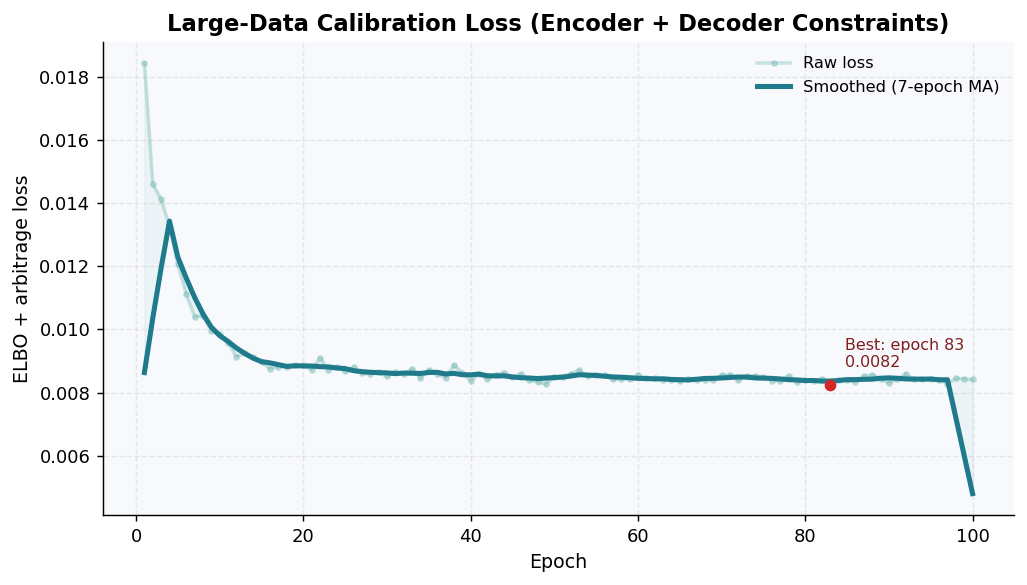

In [38]:
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)
from helper_module.vae_surface import (
    ArbitrageAwareConfig,
    TrainConfig,
    train_vae_arbitrage_aware,
)

n_train_big = 1000
epochs_big = 100

n_sabr_big = int(round(n_train_big * SABR_MIX_WEIGHT))
n_ssvi_big = n_train_big - n_sabr_big
surfaces_big = np.vstack([
    make_synthetic_sabr_surfaces(n_sabr_big, rng=rng),
    make_synthetic_ssvi_surfaces(n_ssvi_big, rng=rng),
])
rng.shuffle(surfaces_big, axis=0)
print(f"Large-run training mix: SABR weight={SABR_MIX_WEIGHT:.2f}, SSVI weight={1.0 - SABR_MIX_WEIGHT:.2f}")
cfg_big = TrainConfig(
    epochs=epochs_big,
    batch_size=256,
    latent_dim=16,
    lr=8e-4,
    kl_weight=0.35,
)

# Rebalanced regularization to avoid over-smoothing / mode collapse.
# Keep constraints, but make them gentle enough to preserve smile curvature.
arb_big = ArbitrageAwareConfig(
    forward=0.03,
    constrained_strike_decoder=False,
    enforce_full_noarb_layer=False,
    lambda_arb=0.7,
    butterfly_weight=4.0,
    sticky_weight=0.6,
    prior_arb_weight=0.2,
    smoothness_weight=0.05,
    smoothness_tenor_weight=1.0,
    smoothness_delta_weight=0.25,
    repair_targets=True,
    repair_max_iter=10,
    repair_retry_scales=(1, 2, 4),
    strict_repair_targets=True,
    min_repaired_fraction=0.9,
)

print("Large-data run config:", arb_big)
print("Repairing training targets strictly + decoder loss constraints during calibration...")
model_big, losses_big = train_vae_arbitrage_aware(surfaces_big, cfg_big, arb_big)

epochs_big_arr = np.arange(1, len(losses_big) + 1)
losses_big_arr = np.asarray(losses_big, dtype=float)
win_big = min(7, len(losses_big_arr))
if win_big >= 2:
    kernel_big = np.ones(win_big) / win_big
    smooth_big = np.convolve(losses_big_arr, kernel_big, mode="same")
else:
    smooth_big = losses_big_arr

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=130)
ax.set_facecolor("#f7f9fc")
ax.plot(epochs_big_arr, losses_big_arr, color="#72b7b2", lw=2.0, alpha=0.35, marker="o", ms=2.8, label="Raw loss")
ax.plot(epochs_big_arr, smooth_big, color="#1f7a8c", lw=2.8, label=f"Smoothed ({win_big}-epoch MA)")
ax.fill_between(epochs_big_arr, smooth_big, losses_big_arr, color="#72b7b2", alpha=0.08)

ax.set_title("Large-Data Calibration Loss (Encoder + Decoder Constraints)", fontsize=12.5, weight="bold")
ax.set_xlabel("Epoch", fontsize=10.5)
ax.set_ylabel("ELBO + arbitrage loss", fontsize=10.5)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

best_ep_big = int(np.argmin(losses_big_arr)) + 1
best_val_big = float(np.min(losses_big_arr))
ax.scatter([best_ep_big], [best_val_big], color="#d62728", s=30, zorder=5)
ax.annotate(
    f"Best: epoch {best_ep_big}\n{best_val_big:.4f}",
    xy=(best_ep_big, best_val_big),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=8.8,
    color="#7f1d1d",
)

plt.tight_layout()
plt.show()

**NB Cell operations:** Second large experiment: mixed SABR+SSVI data, **unconstrained** decoder (`constrained_strike_decoder=False`) with **soft** arbitrage + smoothness penalties, **strict repaired training targets** (`repair_targets=True`, `strict_repair_targets=True`) so only feasible targets enter the loss when repair succeeds. Trains for `epochs_big` with `train_vae_arbitrage_aware` and plots the total training loss.

**Outputs:** Prints the `ArbitrageAwareConfig` used, training progress from the loop, and a loss curve (raw + smoothed). The trained `model_big` is used for sampling and diagnostics below. (If `n_train_big` is smaller than the markdown in §5 suggests, the run is still valid—it is the count in code that matters.)


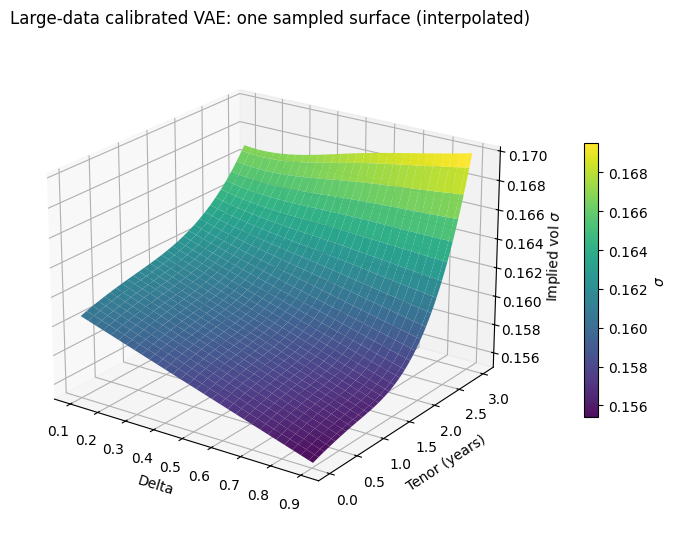

In [65]:
# One sampled surface from the calibrated large-data VAE
model_big.eval()
device_big = next(model_big.parameters()).device
with torch.no_grad():
    z_plot = torch.randn(1, cfg_big.latent_dim, device=device_big)
    gen_plot = model_big.decode(z_plot).cpu().numpy().squeeze(0)

mat_plot = gen_plot.reshape(len(TENORS_YEARS), len(DELTAS))

# Interpolate to a denser plotting grid for smoother rendering.
n_t_fine = 60
n_d_fine = 60
tenors_fine = np.linspace(float(TENORS_YEARS.min()), float(TENORS_YEARS.max()), n_t_fine)
deltas_fine = np.linspace(float(DELTAS.min()), float(DELTAS.max()), n_d_fine)
spline = RectBivariateSpline(TENORS_YEARS, DELTAS, mat_plot, kx=3, ky=3)
mat_plot_fine = spline(tenors_fine, deltas_fine)
T_grid_plot, D_grid_plot = np.meshgrid(tenors_fine, deltas_fine, indexing="ij")

fig = plt.figure(figsize=(8.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    D_grid_plot,
    T_grid_plot,
    mat_plot_fine,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)
ax.set_xlabel("Delta")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel(r"Implied vol $\sigma$")
ax.set_title("Large-data calibrated VAE: one sampled surface (interpolated)")
ax.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.55, label=r"$\sigma$", pad=0.08)
plt.tight_layout()
plt.show()

**NB Cell operations:** Draws one latent sample from `model_big`, decodes vols, and builds a **smoother 3D plot** by **bicubic spline interpolation** (`RectBivariateSpline`) between the discrete tenor/delta nodes.

**Outputs:** A single 3D surface figure—the interpolation is **for visualization only**; arbitrage checks elsewhere use the **raw** grid values.


In [ ]:
importlib.reload(helper_module.arbitrage)
importlib.reload(helper_module.vae_vol_surface)
importlib.reload(helper_module.vae_surface)
from helper_module.vae_surface import surface_smoothness_penalty_torch

# Evaluate sampled decoder outputs under the same discrete checker.
K_big = strikes_for_surface_grid(0.03)
model_big.eval()
n_eval = 5000
passes = 0
viol_counts = []

n_any_arb = 0
n_strike_arb = 0
n_sticky_arb = 0
n_both_arb = 0

smooth_vals = []

n_t, n_d = len(TENORS_YEARS), len(DELTAS)
with torch.no_grad():
    z_big = torch.randn(n_eval, cfg_big.latent_dim, device=next(model_big.parameters()).device)
    dec_big = model_big.decode(z_big)
    gen_big = dec_big.cpu().numpy()
    gen_big_mat = gen_big.reshape(n_eval, n_t, n_d)

    # Batch smoothness diagnostic on generated surfaces.
    smooth_all = surface_smoothness_penalty_torch(
        dec_big,
        tenor_weight=arb_big.smoothness_tenor_weight,
        delta_weight=arb_big.smoothness_delta_weight,
    )

# Vectorized per-sample smoothness for distribution stats.
if n_t >= 3:
    d2_t = gen_big_mat[:, 2:, :] - 2.0 * gen_big_mat[:, 1:-1, :] + gen_big_mat[:, :-2, :]
    smooth_t = np.mean(d2_t**2, axis=(1, 2))
else:
    smooth_t = np.zeros(gen_big.shape[0])
if n_d >= 3:
    d2_d = gen_big_mat[:, :, 2:] - 2.0 * gen_big_mat[:, :, 1:-1] + gen_big_mat[:, :, :-2]
    smooth_d = np.mean(d2_d**2, axis=(1, 2))
else:
    smooth_d = np.zeros(gen_big.shape[0])
smooth_vals = (
    arb_big.smoothness_tenor_weight * smooth_t
    + arb_big.smoothness_delta_weight * smooth_d
)

for i in range(n_eval):
    mat_i = gen_big_mat[i]
    rep_i = validate_vol_surface_per_expiry_black76(K_big, TENORS_YEARS, mat_i, forward=0.03)

    passes += int(rep_i.ok)
    viol_counts.append(len(rep_i.violations))

    has_strike = any("Sticky-delta" not in msg for msg in rep_i.violations)
    has_sticky = any("Sticky-delta" in msg for msg in rep_i.violations)

    if has_strike or has_sticky:
        n_any_arb += 1
    if has_strike:
        n_strike_arb += 1
    if has_sticky:
        n_sticky_arb += 1
    if has_strike and has_sticky:
        n_both_arb += 1


print(f"Raw decoder after encoder+decoder constrained calibration — arbitrage-free samples: {passes}/{n_eval} = {passes/n_eval:.1%}")
print(f"Samples with any arbitrage: {n_any_arb}/{n_eval} = {n_any_arb/n_eval:.1%}")
print(f"Samples with strike arbitrage: {n_strike_arb}/{n_eval} = {n_strike_arb/n_eval:.1%}")
print(f"Samples with sticky-delta arbitrage: {n_sticky_arb}/{n_eval} = {n_sticky_arb/n_eval:.1%}")
print(f"Samples with both strike + sticky: {n_both_arb}/{n_eval} = {n_both_arb/n_eval:.1%}")
print(f"Mean violations per sample: {np.mean(viol_counts):.2f}")
print(f"Median violations per sample: {np.median(viol_counts):.2f}")
print(f"Min/Max violations: {np.min(viol_counts)} / {np.max(viol_counts)}")
print(f"Smoothness penalty (batch): {float(smooth_all.item()):.6g}")
print(f"Smoothness per sample mean/median/min/max: {np.mean(smooth_vals):.6g} / {np.median(smooth_vals):.6g} / {np.min(smooth_vals):.6g} / {np.max(smooth_vals):.6g}")

Raw decoder after encoder+decoder constrained calibration — arbitrage-free samples: 4523/5000 = 90.5%
Samples with any arbitrage: 477/5000 = 9.5%
Samples with strike arbitrage: 477/5000 = 9.5%
Samples with sticky-delta arbitrage: 0/5000 = 0.0%
Samples with both strike + sticky: 0/5000 = 0.0%
Mean violations per sample: 0.11
Median violations per sample: 0.00
Min/Max violations: 0 / 3
Smoothness penalty (batch): 3.00482e-05
Smoothness per sample mean/median/min/max: 3.00482e-05 / 2.71199e-05 / 1.00574e-07 / 0.00013542


**NB Cell operations:** **Monte Carlo evaluation** of the large-data model: decodes `n_eval` random surfaces, reshapes to `(n_eval, 8, 5)`, runs the discrete checker on each, aggregates **how many samples are fully arbitrage-free**, strike-only / sticky-only / both, violation counts, and **smoothness** statistics (batch penalty plus per-sample second-difference roughness on tenor and delta).

**Outputs:** Summary **pass rates** and violation histograms in the log, plus smoothness mean/median/min/max. Use these numbers to judge sampling quality after calibration—not every sample will pass unless the model and penalties are very strong.


## 6. Notes

- **Arbitrage:** Discrete checks are in `helper_module.arbitrage`. Section 4 uses `train_vae_arbitrage_aware` with `constrained_strike_decoder=True` so each expiry slice has no strike butterfly/monotonicity violations by construction; calendar consistency is still trained, not hard-coded.
- **Data:** Training uses a mixed synthetic **SABR + SSVI** sample by default.
- **Theory note (SABR vs SSVI):** SABR is a dynamic stochastic-vol diffusion model; practical implied vols are usually generated with Hagan-style approximation (not a strict global static-arbitrage guarantee by itself). SSVI is a static total-variance parameterization motivated by Heston asymptotics. In SSVI, 
  \(w(k,\theta)=\frac{\theta}{2}\left(1+\rho\,\phi(\theta)k+\sqrt{(\phi(\theta)k+\rho)^2+1-\rho^2}\right)\), with \(k=\log(K/F)\) and commonly \(\phi(\theta)=\eta\,\theta^{-\gamma}\). Under the Gatheral–Jacquier admissibility constraints (calendar monotonicity in \(\theta\) and butterfly bounds on \(\theta\phi(\theta)\) and \(\rho\)), SSVI can be made statically arbitrage-free by construction.
- **Hyperparameters:** Learning rate, batch size, and latent dimension are experimental knobs and should be re-tuned on held-out periods.